In [24]:
%pip install gensim
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [25]:
from gensim.models import Word2Vec

sentences = [
    ["gato", "come", "peixe"],
    ["gata", "come", "peixe"],
    ["cachorro","come","carne"],
    ["gato", "e", "cachorro", "sao", "animais"]
]

# Treinando o modelo
# vector_size: tamanho do vetor (embedding)
# window: janela de contexto
# min_count: ignora palavras que aparecem menos X vezes
model = Word2Vec(sentences, vector_size=2, window=5, min_count=1)
print(model.wv["gato"])
print(model.wv["cachorro"])

[0.32294363 0.4486494 ]
[0.25511047 0.45049587]


In [26]:
model.wv.similarity("gato", "gata")
#model.wv.similarity("gato", "animais")

np.float32(0.8168584)

In [27]:
model.wv.most_similar("gato")

[('cachorro', 0.9941047430038452),
 ('gata', 0.8168585300445557),
 ('sao', 0.40688490867614746),
 ('e', 0.33441224694252014),
 ('come', -0.20711536705493927),
 ('carne', -0.8313262462615967),
 ('animais', -0.9543962478637695),
 ('peixe', -0.9571326971054077)]

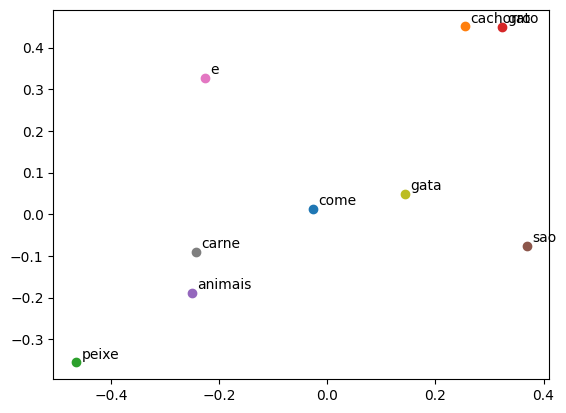

In [28]:
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)

for word in words:
    x, y = model.wv[word]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.show()

In [29]:
model.wv.most_similar("gato")

[('cachorro', 0.9941047430038452),
 ('gata', 0.8168585300445557),
 ('sao', 0.40688490867614746),
 ('e', 0.33441224694252014),
 ('come', -0.20711536705493927),
 ('carne', -0.8313262462615967),
 ('animais', -0.9543962478637695),
 ('peixe', -0.9571326971054077)]

In [30]:
model.wv.most_similar(
    positive=['gato', 'come'],
    negative=['peixe']
)

[('cachorro', 0.9647590517997742),
 ('e', 0.6562886834144592),
 ('gata', 0.5488901138305664),
 ('sao', 0.0441192165017128),
 ('carne', -0.570062518119812),
 ('animais', -0.7787826657295227)]